# Gemini-Logical Reproduction of Magic-State Distillation

This notebook reproduces the **encoded distillation** part of [`magic_state_distillation.py`](/Users/jasonhan/Downloads/magic_state_distillation.py), but uses `@gemini.logical.kernel` so that each logical qubit is realized as a `[[7,1,3]]` Steane block by the Gemini logical lowering pipeline.

The goal here is intentionally modest:
- mirror the logical 5-to-1 MSD circuit and tomography branches,
- avoid decoders entirely,
- test whether simple postselection alone can improve over the injected logical magic-state fidelity.

Because Gemini's raw logical-observable convention is not identical to the reference script's convention, the notebook empirically calibrates:
- the raw factory-acceptance branch in the current observable convention,
- the sign frame of the distilled output Bloch vector.

This keeps the notebook focused on the Steane-encoded Gemini analogue of the reference implementation.

In [32]:
import math
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

# NOTE: this is kind of a hack because the msd_utils code isn't incorporated into the actual lib code yet.
PROJECT_ROOT_CANDIDATES = [Path.cwd(), Path.cwd().parent]
for candidate in PROJECT_ROOT_CANDIDATES:
    candidate = candidate.resolve()
    if (candidate / 'demo' / 'msd_utils').exists():
        sys.path.insert(0, str(candidate))
        break
else:
    raise FileNotFoundError('Could not locate repo root containing demo/msd_utils.')

from bloqade.lanes import GeminiLogicalSimulator
from bloqade.lanes.steane_defaults import steane7_m2dets, steane7_m2obs

from demo.msd_utils.core import (
    DEFAULT_BASIS_LABELS,
    DEFAULT_IDEAL_FACTORY_ACCEPTANCE,
    DEFAULT_TARGET_BLOCH,
    infer_distilled_sign_vector,
    infer_factory_target,
    naive_distilled_summary,
    naive_injected_summary,
)
from demo.msd_utils.circuits import (
    build_naive_kernel_bundle,
    build_task_map,
    make_noisy_steane7_initializer,
)


In [33]:
DEFAULT_BASIS_LABELS

('X', 'Y', 'Z')

In [34]:
DEFAULT_IDEAL_FACTORY_ACCEPTANCE

0.16666666666666666

In [35]:
DEFAULT_TARGET_BLOCH

array([0.57735027, 0.57735027, 0.57735027])

In [36]:
# This should give the state (1, 1, 1)
THETA = 0.3041 * math.pi
PHI = 0.25 * math.pi
LAM = 0.0

# P_PREP = 0.05
FAST_SHOTS = 200_000
POSTERIOR_SAMPLES = 20_000

BASIS_LABELS = DEFAULT_BASIS_LABELS
OUTPUT_QUBIT = 0
ANCILLA_QUBITS = (1, 2, 3, 4)
IDEAL_FACTORY_ACCEPTANCE = DEFAULT_IDEAL_FACTORY_ACCEPTANCE
TARGET_BLOCH = DEFAULT_TARGET_BLOCH

M2DETS_5 = steane7_m2dets(5)
M2OBS_5 = steane7_m2obs(5)
M2DETS_1 = steane7_m2dets(1)
M2OBS_1 = steane7_m2obs(1)


In [37]:
# M2DETS_5

In [38]:
# M2DETS_1

In [39]:
# M2OBS_5

In [40]:
# M2OBS_1

In [41]:
OUTPUT_QUBIT

0

In [42]:
kernel_bundle = build_naive_kernel_bundle(THETA, PHI, LAM, output_qubit=OUTPUT_QUBIT)
DISTILLED_KERNELS = kernel_bundle.distilled
INJECTED_KERNELS = kernel_bundle.injected


In [43]:
kernel_bundle

NaiveKernelBundle(distilled={'X': Method("distilled_x"), 'Y': Method("distilled_y"), 'Z': Method("distilled_z")}, injected={'X': Method("injected_x"), 'Y': Method("injected_y"), 'Z': Method("injected_z")})

In [44]:
kernel_bundle.distilled["Z"].print()

func.func @distilled_z() -> !py.NoneType {
  ^0(%distilled_z_self):
  │      %qubit = qubit.new() : !py.Qubit
  │          %0 = qubit.new() : !py.Qubit
  │          %1 = qubit.new() : !py.Qubit
  │          %2 = qubit.new() : !py.Qubit
  │          %3 = qubit.new() : !py.Qubit
  │        %reg = py.ilist.new(values=(%qubit, %0, %1, %2, %3)){elem_type=!Any} : !py.IList[!py.Qubit, Literal(5,int)]
  │          %4 = py.constant.constant 0.15205 : !py.float
  │          %5 = py.constant.constant 0.125 : !py.float
  │          %6 = py.constant.constant 0.0 : !py.float
  │               squin.gate.u3(theta=%4, phi=%5, lam=%6, qubits=%reg)
  │     %qubits = py.ilist.new(values=(%qubit, %0, %3)){elem_type=!Any} : !py.IList[!py.Qubit, Literal(3,int)]
  │               squin.gate.sqrt_x(qubits=%qubits){adjoint=False : !py.bool}
  │   %controls = py.ilist.new(values=(%qubit, %1)){elem_type=!Any} : !py.IList[!py.Qubit, Literal(2,int)]
  │    %targets = py.ilist.new(values=(%0, %2)){elem_type=!Any} :

In [45]:
kernel_bundle.injected["Z"].print()

func.func @injected_z() -> !py.NoneType {
  ^0(%injected_z_self):
  │  %qubit = qubit.new() : !py.Qubit
  │ %qubits = py.ilist.new(values=(%qubit)){elem_type=!py.Qubit} : !py.IList[!py.Qubit, Literal(1,int)]
  │      %0 = py.constant.constant 0.15205 : !py.float
  │      %1 = py.constant.constant 0.125 : !py.float
  │      %2 = py.constant.constant 0.0 : !py.float
  │           squin.gate.u3(theta=%0, phi=%1, lam=%2, qubits=%qubits)
  │      %3 = func.const.none() : !py.NoneType
  │           func.return %3
} // func.func injected_z


In [46]:
# DISTILLED_KERNELS["X"].print()

### Clifford Flow Check

Stim flow generators only work for Clifford circuits, so this diagnostic strips off the non-Clifford magic-state preparation and checks the stabilizer flow of the logical distillation block itself. This is a good sanity check that the distilled logical circuit skeleton matches the expected 5-to-1 MSD Clifford.


In [47]:
import stim
from bloqade import squin
from bloqade.squin import kernel
from bloqade.tsim import Circuit

def make_reprod_clifford_flow_kernel(basis: str = "Z"):
    @kernel
    def flow_kernel():
        reg = squin.qalloc(5)
        squin.broadcast.reset(reg)
        squin.broadcast.sqrt_x([reg[0], reg[1], reg[4]])
        squin.broadcast.cz([reg[0], reg[2]], [reg[1], reg[3]])
        squin.broadcast.sqrt_y([reg[0], reg[3]])
        squin.broadcast.cz([reg[0], reg[3]], [reg[2], reg[4]])
        squin.broadcast.sqrt_x_adj([reg[0]])
        squin.broadcast.cz([reg[0], reg[1]], [reg[4], reg[3]])
        squin.broadcast.sqrt_x_adj(reg)

        if basis == "X":
            squin.h(reg[0])
        elif basis == "Y":
            squin.sqrt_z_adj(reg[0])
            squin.h(reg[0])

        squin.broadcast.measure(reg)

    return flow_kernel

REPROD_LOGICAL_DISTILLATION_FLOWS = {
    basis: stim.Circuit(str(Circuit(make_reprod_clifford_flow_kernel(basis)))).flow_generators()
    for basis in BASIS_LABELS
}

for basis in BASIS_LABELS:
    print(f"{basis} basis: {len(REPROD_LOGICAL_DISTILLATION_FLOWS[basis])} flows")
    for flow in REPROD_LOGICAL_DISTILLATION_FLOWS[basis]:
        print(flow)
    print()


X basis: 5 flows
1 -> ____Z xor rec[4]
1 -> ___Z_ xor rec[3]
1 -> __Z__ xor rec[2]
1 -> _Z___ xor rec[1]
1 -> Z____ xor rec[0]

Y basis: 5 flows
1 -> ____Z xor rec[4]
1 -> ___Z_ xor rec[3]
1 -> __Z__ xor rec[2]
1 -> _Z___ xor rec[1]
1 -> Z____ xor rec[0]

Z basis: 6 flows
1 -> rec[0] xor rec[1] xor rec[3]
1 -> ____Z xor rec[4]
1 -> ___Z_ xor rec[3]
1 -> __Z__ xor rec[2]
1 -> _Z___ xor rec[1]
1 -> Z____ xor rec[1] xor rec[3]



### adding noise to state init circ

In [48]:
# from bloqade.lanes.transform import MoveToSquin
# from bloqade.lanes.arch.gemini.impls import generate_arch_hypercube

In [49]:
sim = GeminiLogicalSimulator()

In [50]:
sim = GeminiLogicalSimulator()
noisy_steane7_initialize = make_noisy_steane7_initializer(sim)


In [51]:
noisy_steane7_initialize.print()

func.func @noisy_steane7_initialize(theta : !Any, phi : !Any, lam : !Any, qubits : !Any) -> !py.NoneType {
  ^0(%noisy_steane7_initialize_self, %theta, %phi, %lam, %qubits):
  │         %0 = py.constant.constant slice(None, None, 2) : !py.slice
  │     %evens = py.indexing.getitem(%qubits, %0) : !Any
  │         %1 = py.constant.constant slice(1, None, 2) : !py.slice
  │      %odds = py.indexing.getitem(%qubits, %1) : !Any
  │         %2 = py.constant.constant 6 : !py.int
  │         %3 = py.indexing.getitem(%qubits, %2) : !Any
  │         %4 = func.invoke u3(%theta, %phi, %lam, %3) : !py.NoneType maybe_pure=False
  │         %5 = py.constant.constant 6 : !py.int
  │         %6 = py.indexing.getitem(%qubits, %5) : !Any
  │         %7 = py.ilist.new(values=(%6)){elem_type=!Any} : !py.IList[!Any, Literal(1,int)]
  │         %8 = py.constant.constant 0.0 : !py.float
  │         %9 = py.constant.constant 0.5 : !py.float
  │        %10 = func.invoke local_r_noise(%7, %8, %9) : !py.NoneType 

In [52]:
distilled_tasks = build_task_map(
    sim,
    DISTILLED_KERNELS,
    m2dets=M2DETS_5,
    m2obs=M2OBS_5,
    noisy_initializer=noisy_steane7_initialize,
    append_measurements=True,
)
injected_tasks = build_task_map(
    sim,
    INJECTED_KERNELS,
    m2dets=M2DETS_1,
    m2obs=M2OBS_1,
    noisy_initializer=noisy_steane7_initialize,
    append_measurements=True,
)

print("Built tasks:", list(distilled_tasks), list(injected_tasks))


Built tasks: ['X', 'Y', 'Z'] ['X', 'Y', 'Z']


In [53]:
distilled_tasks

{'X': GeminiLogicalSimulatorTask(logical_squin_kernel=Method("distilled_x"), noise_model=SimpleNoiseModel(lane_noise=Method("lane_noise"), idle_noise=Method("idle_noise"), cz_unpaired_noise=Method("cz_unpaired_noise"), cz_paired_noise=Method("cz_paired_noise"), global_rz_noise=Method("global_rz_noise"), local_rz_noise=Method("local_rz_noise"), global_r_noise=Method("global_r_noise"), local_r_noise=Method("local_r_noise")), _thread_pool_executor=<concurrent.futures.thread.ThreadPoolExecutor object at 0x144532000>),
 'Y': GeminiLogicalSimulatorTask(logical_squin_kernel=Method("distilled_y"), noise_model=SimpleNoiseModel(lane_noise=Method("lane_noise"), idle_noise=Method("idle_noise"), cz_unpaired_noise=Method("cz_unpaired_noise"), cz_paired_noise=Method("cz_paired_noise"), global_rz_noise=Method("global_rz_noise"), local_rz_noise=Method("local_rz_noise"), global_r_noise=Method("global_r_noise"), local_r_noise=Method("local_r_noise")), _thread_pool_executor=<concurrent.futures.thread.Thre

In [54]:
%matplotlib qt

In [55]:
distilled_tasks["X"].physical_move_kernel.print()

func.func @distilled_x() -> !Bottom {
  ^0(%distilled_x_self):
  │       %0 = lanes.move.load() : !py.State
  │       %1 = lanes.move.fill(current_state=%0){location_addresses=(0x0000000000000000, 0x0000000000010000, 0x0000000000020000, 0x0000000000030000, 0x0000000000040000, 0x0000000000050000, 0x0000000000060000, 0x0000000000000001, 0x0000000000010001, 0x0000000000020001, 0x0000000000030001, 0x0000000000040001, 0x0000000000050001, 0x0000000000060001, 0x0000000000000002, 0x0000000000010002, 0x0000000000020002, 0x0000000000030002, 0x0000000000040002, 0x0000000000050002, 0x0000000000060002, 0x0000000000000003, 0x0000000000010003, 0x0000000000020003, 0x0000000000030003, 0x0000000000040003, 0x0000000000050003, 0x0000000000060003, 0x0000000000000004, 0x0000000000010004, 0x0000000000020004, 0x0000000000030004, 0x0000000000040004, 0x0000000000050004, 0x0000000000060004) : !py.tuple[!py.LocationAddress, ...]} : !py.State
  │            lanes.move.store(current_state=%1)
  │       %2 = py.cons

In [56]:
from IPython.display import HTML, display

def display_circ(diagram):

    # diagram = distilled_tasks["X"].tsim_circuit.diagram(height=500)
    display(HTML(f"""
    <div style="background: white; padding: 12px;">
    {diagram}
    </div>
    """))

In [58]:

display_circ(distilled_tasks["Z"].noiseless_tsim_circuit.diagram(height=500))

In [59]:
from demo.msd_utils.core import logical_expectation, run_task

shots = 1000000

x_data = run_task(distilled_tasks["X"], shots, with_noise=False, chunk_size=10000)
y_data = run_task(distilled_tasks["Y"], shots, with_noise=False, chunk_size=10000)
z_data = run_task(distilled_tasks["Z"], shots, with_noise=False, chunk_size=10000)

ex = logical_expectation(x_data.observables[:, 0])
ey = logical_expectation(y_data.observables[:, 0])
ez = logical_expectation(z_data.observables[:, 0])

print("Noiseless <X>, <Y>, <Z> =", (ex, ey, ez))

Noiseless <X>, <Y>, <Z> = (0.191636, -0.19152, 0.192044)


In [62]:
FACTORY_TARGET = np.array([0, 0, 0, 0])

In [63]:
def accepted_output_bits(data, factory_target):
    perfect_stabilizers = np.all(data.detectors == 0, axis=1)
    correct_syndrome = np.all(data.observables[:, 1:] == factory_target, axis=1)
    mask = perfect_stabilizers & correct_syndrome
    return {
        "bits": data.observables[mask, 0].astype(np.uint8),
        "rate_total": float(mask.mean()),
        "rate_stabilizers": float(perfect_stabilizers.mean()),
        "rate_syndrome_given_stabilizers": (
            float(mask.sum() / perfect_stabilizers.sum())
            if perfect_stabilizers.sum() > 0
            else float("nan")
        ),
    }

x = accepted_output_bits(x_data, FACTORY_TARGET)
y = accepted_output_bits(y_data, FACTORY_TARGET)
z = accepted_output_bits(z_data, FACTORY_TARGET)

print(
    "Accepted noiseless <X>, <Y>, <Z> =",
    (
        logical_expectation(x["bits"]),
        logical_expectation(y["bits"]),
        logical_expectation(z["bits"]),
    ),
)

print("Total postselection rates =", (x["rate_total"], y["rate_total"], z["rate_total"]))
print(
    "Perfect stabilizer rates =",
    (x["rate_stabilizers"], y["rate_stabilizers"], z["rate_stabilizers"]),
)
print(
    "Syndrome rates given perfect stabilizers =",
    (
        x["rate_syndrome_given_stabilizers"],
        y["rate_syndrome_given_stabilizers"],
        z["rate_syndrome_given_stabilizers"],
    ),
)

Accepted noiseless <X>, <Y>, <Z> = (0.6081594902887678, -0.5767725985310355, 0.5772556492350837)
Total postselection rates = (0.19462, 0.166648, 0.166881)
Perfect stabilizer rates = (1.0, 1.0, 1.0)
Syndrome rates given perfect stabilizers = (0.19462, 0.166648, 0.166881)


### Noiseless Factory-Branch Debugging

This section helps compare the **reported Steane ancilla observable bits** in this notebook against the bare logical MSD branch you may expect from the unencoded 5-qubit circuit. It prints the dominant noiseless ancilla branches for each tomography basis and gives a helper for checking candidate targets such as `1011` and `0000`.


In [82]:
from collections import Counter


def branch_histogram(data):
    counts = Counter(tuple(int(x) for x in row) for row in data.observables[:, 1:])
    total = len(data.observables)
    return [(pattern, count / total) for pattern, count in counts.most_common()]


def accepted_output_bits_and_fraction(data, factory_target):
    target = np.asarray(factory_target, dtype=np.uint8)
    mask = np.all(data.observables[:, 1:] == target, axis=1)
    return data.observables[mask, 0].astype(np.uint8), float(mask.mean())


def summarize_factory_target(factory_target):
    print(f"\nFactory target {tuple(int(x) for x in factory_target)}")
    for basis, data in [("X", x_data), ("Y", y_data), ("Z", z_data)]:
        bits, frac = accepted_output_bits_and_fraction(data, factory_target)
        exp = logical_expectation(bits) if len(bits) else float("nan")
        print(f"  {basis}: accepted_fraction={frac:.5f}, raw_expectation={exp:.6f}, shots={len(bits)}")


for basis, data in [("X", x_data), ("Y", y_data), ("Z", z_data)]:
    print(f"\nTop noiseless ancilla branches for {basis}:")
    for pattern, frac in branch_histogram(data)[:8]:
        print(f"  {pattern}: {frac:.5f}")

for candidate in [
    np.array([1, 0, 1, 1], dtype=np.uint8),
    np.array([0, 0, 0, 0], dtype=np.uint8),
]:
    summarize_factory_target(candidate)



Top noiseless ancilla branches for X:
  (0, 0, 0, 0): 0.18945
  (0, 1, 1, 0): 0.08350
  (1, 1, 1, 0): 0.07855
  (0, 0, 1, 0): 0.07825
  (1, 0, 0, 0): 0.07760
  (0, 1, 0, 0): 0.07750
  (1, 1, 0, 0): 0.07010
  (1, 0, 1, 0): 0.06805

Top noiseless ancilla branches for Y:
  (0, 0, 0, 0): 0.16775
  (0, 0, 1, 0): 0.05865
  (0, 1, 1, 0): 0.05715
  (1, 1, 1, 0): 0.05690
  (0, 1, 0, 0): 0.05665
  (1, 0, 1, 1): 0.05640
  (0, 1, 1, 1): 0.05585
  (0, 0, 1, 1): 0.05580

Top noiseless ancilla branches for Z:
  (0, 0, 0, 0): 0.17080
  (0, 1, 0, 0): 0.05735
  (0, 0, 1, 1): 0.05620
  (0, 0, 1, 0): 0.05615
  (0, 1, 0, 1): 0.05575
  (1, 1, 0, 0): 0.05565
  (1, 0, 1, 0): 0.05550
  (1, 0, 0, 0): 0.05530

Factory target (1, 0, 1, 1)
  X: accepted_fraction=0.04195, raw_expectation=0.230036, shots=839
  Y: accepted_fraction=0.05640, raw_expectation=-0.576241, shots=1128
  Z: accepted_fraction=0.05480, raw_expectation=0.547445, shots=1096

Factory target (0, 0, 0, 0)
  X: accepted_fraction=0.18945, raw_expect

In [51]:
injected_tasks

{'X': GeminiLogicalSimulatorTask(logical_squin_kernel=Method("injected_x"), noise_model=SimpleNoiseModel(lane_noise=Method("lane_noise"), idle_noise=Method("idle_noise"), cz_unpaired_noise=Method("cz_unpaired_noise"), cz_paired_noise=Method("cz_paired_noise"), global_rz_noise=Method("global_rz_noise"), local_rz_noise=Method("local_rz_noise"), global_r_noise=Method("global_r_noise"), local_r_noise=Method("local_r_noise")), _thread_pool_executor=<concurrent.futures.thread.ThreadPoolExecutor object at 0x121ddf050>),
 'Y': GeminiLogicalSimulatorTask(logical_squin_kernel=Method("injected_y"), noise_model=SimpleNoiseModel(lane_noise=Method("lane_noise"), idle_noise=Method("idle_noise"), cz_unpaired_noise=Method("cz_unpaired_noise"), cz_paired_noise=Method("cz_paired_noise"), global_rz_noise=Method("global_rz_noise"), local_rz_noise=Method("local_rz_noise"), global_r_noise=Method("global_r_noise"), local_r_noise=Method("local_r_noise")), _thread_pool_executor=<concurrent.futures.thread.Thread

In [52]:
# injected_tasks["X"].physical_squin_kernel.print()

In [15]:
from IPython.display import HTML, display

diagram = distilled_tasks["X"].tsim_circuit.diagram(height=500)
display(HTML(f"""
<div style="background: white; padding: 12px;">
  {diagram}
</div>
"""))

In [ ]:
# # NOTE: infer.. is also kind of a hack.. you can also presupply the target of the distillation factory; this "brute-forces search" it over all possible distillation syndromes
# # and tries to find the syndrome that appears "close" to the ideal factory acceptance. Could be useful, but is not tractable for larger distillation circuits
# # (should be OK for up to 10 logical qubit circuits, like on Gemini Logical)
# FACTORY_TARGET = infer_factory_target(
#     distilled_tasks,
#     shots=12_000,
#     basis_labels=BASIS_LABELS,
#     ideal_factory_acceptance=IDEAL_FACTORY_ACCEPTANCE,
# )
# DISTILLED_SIGN_VECTOR = infer_distilled_sign_vector(
#     distilled_tasks,
#     FACTORY_TARGET,
#     shots=12_000,
#     basis_labels=BASIS_LABELS,
#     target_bloch=TARGET_BLOCH,
# )
# INJECTED_SIGN_VECTOR = np.array([1.0, 1.0, 1.0], dtype=np.float64)

# print("Using factory target:", tuple(int(x) for x in FACTORY_TARGET.tolist()))


Top noiseless ancilla branches:
(0, 0, 0, 0) 0.17666666666666667
(0, 1, 1, 0) 0.0643611111111111
(1, 0, 0, 0) 0.06372222222222222
(0, 0, 1, 0) 0.06286111111111112
(1, 1, 1, 0) 0.06244444444444444
(0, 1, 0, 0) 0.06233333333333333
(1, 0, 1, 0) 0.06133333333333333
(1, 1, 0, 0) 0.059722222222222225
Noiseless accepted-branch Bloch: [ 0.60118293 -0.57492654  0.58069382]
Chosen distilled sign vector: [ 1. -1.  1.] score: 1.0142908527264851
Using factory target: (0, 0, 0, 0)


In [43]:
FACTORY_TARGET

array([0, 0, 0, 0], dtype=uint8)

In [17]:
inj_raw = naive_injected_summary(
    injected_tasks,
    sign_vector=INJECTED_SIGN_VECTOR,
    posterior_samples=POSTERIOR_SAMPLES,
    shots=FAST_SHOTS,
    require_zero_detectors=False,
    basis_labels=BASIS_LABELS,
    target_bloch=TARGET_BLOCH,
)
inj_ps = naive_injected_summary(
    injected_tasks,
    sign_vector=INJECTED_SIGN_VECTOR,
    posterior_samples=POSTERIOR_SAMPLES,
    shots=FAST_SHOTS,
    require_zero_detectors=True,
    basis_labels=BASIS_LABELS,
    target_bloch=TARGET_BLOCH,
)
dist_raw = naive_distilled_summary(
    distilled_tasks,
    FACTORY_TARGET,
    sign_vector=DISTILLED_SIGN_VECTOR,
    posterior_samples=POSTERIOR_SAMPLES,
    shots=FAST_SHOTS,
    require_zero_ancilla_detectors=False,
    basis_labels=BASIS_LABELS,
    target_bloch=TARGET_BLOCH,
)
dist_flagged = naive_distilled_summary(
    distilled_tasks,
    FACTORY_TARGET,
    sign_vector=DISTILLED_SIGN_VECTOR,
    posterior_samples=POSTERIOR_SAMPLES,
    shots=FAST_SHOTS,
    require_zero_ancilla_detectors=True,
    basis_labels=BASIS_LABELS,
    target_bloch=TARGET_BLOCH,
)

for name, summary in [
    ("Injected raw", inj_raw),
    ("Injected perfect-stabilizer", inj_ps),
    ("Distilled raw branch", dist_raw),
    ("Distilled + zero ancilla detectors", dist_flagged),
]:
    print(name)
    print(summary)
    print()


/Users/jasonhan/Desktop/qmain/kirin-workspace/bloqade-lanes/demo/msd_utils/core.py:102: RuntimeWarning: divide by zero encountered in matmul
  fidelities = 0.5 + (corrected_points @ target_bloch) / 2.0
/Users/jasonhan/Desktop/qmain/kirin-workspace/bloqade-lanes/demo/msd_utils/core.py:102: RuntimeWarning: overflow encountered in matmul
  fidelities = 0.5 + (corrected_points @ target_bloch) / 2.0
/Users/jasonhan/Desktop/qmain/kirin-workspace/bloqade-lanes/demo/msd_utils/core.py:102: RuntimeWarning: invalid value encountered in matmul
  fidelities = 0.5 + (corrected_points @ target_bloch) / 2.0


Injected raw
{'point': 0.9643397274984484, 'median': 0.9553564208942945, 'low': 0.955323351299838, 'high': 0.955389490488751, 'bloch': (0.5397, -0.52176, 0.54706), 'accepted_fraction': 1.0, 'accepted_fraction_by_basis': {'X': 1.0, 'Y': 1.0, 'Z': 1.0}}

Injected perfect-stabilizer
{'point': 0.9951202897958509, 'median': 0.9934633785192971, 'low': 0.9932396273275542, 'high': 0.99368712971104, 'bloch': (0.5700851630354388, -0.5664539257488933, 0.5786079067849477), 'accepted_fraction': 0.9375716666666666, 'accepted_fraction_by_basis': {'X': 0.94642, 'Y': 0.920525, 'Z': 0.94577}}

Distilled raw branch
{'point': 0.9135272863982752, 'median': 0.9217026855846246, 'low': 0.921643373643431, 'high': 0.9217619975258182, 'bloch': (0.45935262857393827, -0.49234481245887257, 0.48080309968298696), 'accepted_fraction': 0.11379333333333333, 'accepted_fraction_by_basis': {'X': 0.113845, 'Y': 0.113975, 'Z': 0.11356}, 'factory_target': (0, 0, 0, 0)}

Distilled + zero ancilla detectors
{'point': 0.970646588

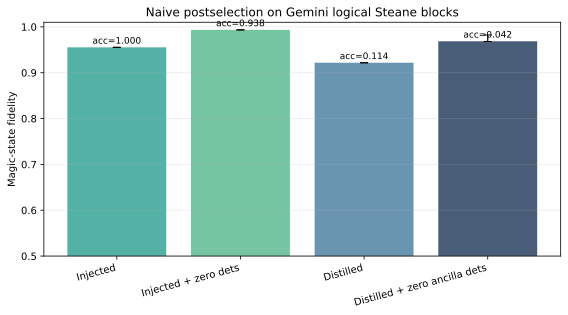

In [18]:
labels = [
    "Injected",
    "Injected + zero dets",
    "Distilled",
    "Distilled + zero ancilla dets",
]
summaries = [inj_raw, inj_ps, dist_raw, dist_flagged]
medians = [summary["median"] for summary in summaries]
lows = [summary["median"] - summary["low"] for summary in summaries]
highs = [summary["high"] - summary["median"] for summary in summaries]
accepted = [summary["accepted_fraction"] for summary in summaries]

fig, ax = plt.subplots(figsize=(8, 4.5))
x = np.arange(len(labels))
ax.bar(x, medians, color=["#2A9D8F", "#52B788", "#457B9D", "#1D3557"], alpha=0.8)
ax.errorbar(x, medians, yerr=[lows, highs], fmt="none", ecolor="black", capsize=4, linewidth=1.2)
ax.set_xticks(x)
ax.set_xticklabels(labels, rotation=15, ha="right")
ax.set_ylabel("Magic-state fidelity")
ax.set_title("Naive postselection on Gemini logical Steane blocks")
ax.set_ylim(0.5, 1.01)
ax.grid(True, axis="y", alpha=0.25)

for xi, fidelity, frac in zip(x, medians, accepted):
    ax.text(xi, fidelity + 0.004, f"acc={frac:.3f}", ha="center", va="bottom", fontsize=9)

plt.tight_layout()
plt.show()